# Musanga and Unsupervised Non-Musanga Canopy Phenotypes — Revised

This notebook combines the existing supervised Musanga U-Net outputs with unsupervised discovery of recurring non-Musanga canopy phenotypes from UAV RGB, DSM, and partial DTM data.

## Workflow

1. Load the existing RGB orthomosaic, DSM, partial DTM, and Musanga outputs.
2. Create a coarser, tiled working grid suitable for canopy analysis.
3. Derive a memory-safe hybrid canopy-height model:
   - actual `DSM − DTM` where the DTM exists;
   - local DSM-relative canopy structure outside DTM coverage.
4. Exclude confidently predicted Musanga canopy.
5. Divide remaining canopy into spatially coherent superpixels.
6. Extract RGB image embeddings with DINOv2 plus colour, texture, and height features.
7. Cluster objects into candidate spectral–structural canopy phenotypes.
8. Produce representative image galleries, cluster summaries, maps, and geospatial exports.

The resulting clusters are **candidate canopy phenotypes**, not automatically botanical species.


## BLOCK 01 — Install and import packages

In [2]:

# ======================================================================================
# BLOCK 01 — INSTALL AND IMPORT PACKAGES
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 01 — INSTALL AND IMPORT PACKAGES")
print("=" * 100)

!pip -q install geopandas rasterio shapely pyogrio rtree scikit-image scipy \
    scikit-learn transformers accelerate joblib

from pathlib import Path
import gc
import json
import math
import random
import warnings

import geopandas as gpd
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import torch

from PIL import Image
from rasterio.enums import Resampling
from rasterio.features import shapes
from rasterio.shutil import copy as rio_copy
from rasterio.vrt import WarpedVRT
from scipy import ndimage as ndi
from shapely.geometry import shape
from skimage import color, filters, morphology, segmentation
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, AutoModel

warnings.filterwarnings("ignore")

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())



BLOCK 01 — INSTALL AND IMPORT PACKAGES
torch: 2.11.0+cu128
CUDA available: True


## BLOCK 02 — Mount Google Drive and define folders

In [3]:

# ======================================================================================
# BLOCK 02 — MOUNT GOOGLE DRIVE AND DEFINE FOLDERS
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 02 — MOUNT GOOGLE DRIVE AND DEFINE FOLDERS")
print("=" * 100)

from google.colab import drive

DRIVE_ROOT = Path("/content/drive")
MYDRIVE = DRIVE_ROOT / "MyDrive"

if not MYDRIVE.exists() or not any(MYDRIVE.iterdir()):
    drive.mount(str(DRIVE_ROOT), force_remount=False)
else:
    print("Google Drive already mounted.")

PROJECT_ROOT = MYDRIVE / "Colab Notebooks" / "Musanga"
DATA_DIR = PROJECT_ROOT / "data"
WORK_DIR = PROJECT_ROOT / "work"

PHENOTYPE_DIR = WORK_DIR / "canopy_phenotypes"
CACHE_DIR = PHENOTYPE_DIR / "cache"
FIGURE_DIR = PHENOTYPE_DIR / "figures"
EXPORT_DIR = PHENOTYPE_DIR / "exports"

for directory in [PHENOTYPE_DIR, CACHE_DIR, FIGURE_DIR, EXPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

LOCAL_DIR = Path("/content/canopy_phenotypes")
LOCAL_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PHENOTYPE_DIR:", PHENOTYPE_DIR)



BLOCK 02 — MOUNT GOOGLE DRIVE AND DEFINE FOLDERS
Google Drive already mounted.
PROJECT_ROOT: /content/drive/MyDrive/Colab Notebooks/Musanga
PHENOTYPE_DIR: /content/drive/MyDrive/Colab Notebooks/Musanga/work/canopy_phenotypes


## BLOCK 03 — Configuration

In [7]:

# ======================================================================================
# BLOCK 03 — CONFIGURATION
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 03 — CONFIGURATION")
print("=" * 100)

# ----------------------------------------------------------------------
# RUN MODE
# ----------------------------------------------------------------------

QUICK_TEST = True
RANDOM_SEED = 42

# ----------------------------------------------------------------------
# INPUT PATHS
# ----------------------------------------------------------------------

RGB_PATH = (
    DATA_DIR
    / "Carlier2020_Aug24_25_survey_transparent_mosaic_group1.tif"
)

DSM_PATH = (
    DATA_DIR
    / "Carlier2020_Aug24_25_survey_dsm.tif"
)

# Set this manually if automatic discovery in Block 04 does not find it.
DTM_PATH = None

MUSANGA_BINARY_PATH = (
    WORK_DIR
    / "whole_orthomosaic_inference"
    / "musanga_binary_mask_threshold_0.008.tif"
)

MUSANGA_PROBABILITY_PATH = (
    WORK_DIR
    / "whole_orthomosaic_inference"
    / "musanga_probability_uint16.tif"
)

COMPLETE_ZONES_PATH = (
    DATA_DIR
    / "Cadre_allSite_buf.shp"
)

# ----------------------------------------------------------------------
# WORKING GRID AND CANOPY OBJECTS
# ----------------------------------------------------------------------

TARGET_RESOLUTION_M = 0.25

MIN_TREE_HEIGHT_M = 2.0
MIN_OBJECT_AREA_M2 = 2.0
MAX_OBJECT_AREA_M2 = 150.0

if QUICK_TEST:
    SUPERPIXEL_SIZE_M = 12.0
else:
    SUPERPIXEL_SIZE_M = 6.0
SUPERPIXEL_COMPACTNESS = 10.0

MUSANGA_BUFFER_M = 0.75

# ----------------------------------------------------------------------
# SAMPLING, EMBEDDINGS AND CLUSTERING
# ----------------------------------------------------------------------

MAX_OBJECTS = 800 if QUICK_TEST else 6000

CHIP_SIZE_PIXELS = 224

EMBEDDING_MODEL_NAME = "facebook/dinov2-small"

EMBEDDING_BATCH_SIZE = (
    16
    if torch.cuda.is_available()
    else 4
)

N_EMBEDDING_PCS = 24

CANDIDATE_K = [4, 5, 6, 7, 8]

N_REPRESENTATIVES = 12

# ----------------------------------------------------------------------
# CACHE CONTROL
# ----------------------------------------------------------------------

# Set True only when intentionally rebuilding the working rasters.
# The first run of this revised notebook may use True.
FORCE_REBUILD_PREPROCESSING = False

# Set True only when intentionally rebuilding image chips and embeddings.
FORCE_REBUILD_EMBEDDINGS = False

# ----------------------------------------------------------------------
# DEVICE AND REPRODUCIBILITY
# ----------------------------------------------------------------------

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("QUICK_TEST:", QUICK_TEST)
print("TARGET_RESOLUTION_M:", TARGET_RESOLUTION_M)
print("MAX_OBJECTS:", MAX_OBJECTS)
print("DEVICE:", DEVICE)
print("FORCE_REBUILD_PREPROCESSING:", FORCE_REBUILD_PREPROCESSING)



BLOCK 03 — CONFIGURATION
QUICK_TEST: True
TARGET_RESOLUTION_M: 0.25
MAX_OBJECTS: 800
DEVICE: cuda
FORCE_REBUILD_PREPROCESSING: False


## BLOCK 04 — Discover and validate input files

In [5]:

# ======================================================================================
# BLOCK 04 — DISCOVER AND VALIDATE INPUT FILES
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 04 — DISCOVER AND VALIDATE INPUT FILES")
print("=" * 100)

def find_first(root, patterns):
    matches = []
    if root.exists():
        for pattern in patterns:
            matches.extend(root.glob(pattern))
    return sorted(matches)[0] if matches else None

if DTM_PATH is None:
    DTM_PATH = find_first(
        DATA_DIR,
        [
            "**/*DTM*.tif",
            "**/*dtm*.tif",
            "**/*terrain*.tif",
        ],
    )

required = {
    "RGB orthomosaic": RGB_PATH,
    "DSM": DSM_PATH,
    "Musanga binary mask": MUSANGA_BINARY_PATH,
    "Musanga probability raster": MUSANGA_PROBABILITY_PATH,
}

missing = [
    name
    for name, path in required.items()
    if path is None or not Path(path).exists()
]

if missing:
    raise FileNotFoundError(
        "Missing required inputs:\n"
        f"{missing}\n\n"
        "Correct the paths in Block 03."
    )

RGB_PATH = Path(RGB_PATH)
DSM_PATH = Path(DSM_PATH)
DTM_PATH = Path(DTM_PATH) if DTM_PATH is not None else None
MUSANGA_BINARY_PATH = Path(MUSANGA_BINARY_PATH)
MUSANGA_PROBABILITY_PATH = Path(MUSANGA_PROBABILITY_PATH)

print("RGB:", RGB_PATH)
print("DSM:", DSM_PATH)
print("DTM:", DTM_PATH)
print("Musanga binary:", MUSANGA_BINARY_PATH)
print("Musanga probability:", MUSANGA_PROBABILITY_PATH)

if DTM_PATH is None:
    print(
        "\nWARNING: no DTM found. "
        "Outside real DTM coverage, DSM-relative local structure will be used."
    )



BLOCK 04 — DISCOVER AND VALIDATE INPUT FILES
RGB: /content/drive/MyDrive/Colab Notebooks/Musanga/data/Carlier2020_Aug24_25_survey_transparent_mosaic_group1.tif
DSM: /content/drive/MyDrive/Colab Notebooks/Musanga/data/Carlier2020_Aug24_25_survey_dsm.tif
DTM: None
Musanga binary: /content/drive/MyDrive/Colab Notebooks/Musanga/work/whole_orthomosaic_inference/musanga_binary_mask_threshold_0.008.tif
Musanga probability: /content/drive/MyDrive/Colab Notebooks/Musanga/work/whole_orthomosaic_inference/musanga_probability_uint16.tif



## BLOCK 05 — Create optimized working-grid rasters

In [6]:

# ======================================================================================
# BLOCK 05 — CREATE OPTIMIZED WORKING-GRID RASTERS
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 05 — CREATE OPTIMIZED WORKING-GRID RASTERS")
print("=" * 100)

LOCAL_RGB_TILED = LOCAL_DIR / "rgb_tiled_512.tif"

WORKING_RGB_PATH = LOCAL_DIR / "rgb_working_grid.tif"
WORKING_DSM_PATH = LOCAL_DIR / "dsm_working_grid.tif"
WORKING_DTM_PATH = LOCAL_DIR / "dtm_working_grid.tif"
WORKING_MUSANGA_PATH = LOCAL_DIR / "musanga_mask_working_grid.tif"
WORKING_MUSANGA_PROB_PATH = LOCAL_DIR / "musanga_probability_working_grid.tif"

if FORCE_REBUILD_PREPROCESSING:
    for path in [
        WORKING_RGB_PATH,
        WORKING_DSM_PATH,
        WORKING_DTM_PATH,
        WORKING_MUSANGA_PATH,
        WORKING_MUSANGA_PROB_PATH,
    ]:
        if path.exists():
            path.unlink()

# ----------------------------------------------------------------------
# CREATE OR REUSE A LOCALLY TILED RGB SOURCE
# ----------------------------------------------------------------------

def valid_tiled_rgb(path):
    if not path.exists():
        return False
    try:
        with rasterio.open(path) as source:
            return (
                source.count >= 3
                and source.block_shapes[0] == (512, 512)
            )
    except Exception:
        return False

if not valid_tiled_rgb(LOCAL_RGB_TILED):
    print("Creating local tiled RGB source...")

    if LOCAL_RGB_TILED.exists():
        LOCAL_RGB_TILED.unlink()

    rio_copy(
        RGB_PATH,
        LOCAL_RGB_TILED,
        driver="GTiff",
        tiled=True,
        blockxsize=512,
        blockysize=512,
        compress="LZW",
        predictor=2,
        BIGTIFF="YES",
    )
else:
    print("Reusing local tiled RGB source.")

# ----------------------------------------------------------------------
# DEFINE THE COMMON WORKING GRID
# ----------------------------------------------------------------------

with rasterio.open(LOCAL_RGB_TILED) as rgb_source:
    native_resolution = abs(rgb_source.transform.a)

    scale_factor = max(
        1,
        int(round(TARGET_RESOLUTION_M / native_resolution)),
    )

    WORK_WIDTH = math.ceil(rgb_source.width / scale_factor)
    WORK_HEIGHT = math.ceil(rgb_source.height / scale_factor)

    WORK_TRANSFORM = (
        rgb_source.transform
        * rasterio.Affine.scale(scale_factor, scale_factor)
    )

    WORK_CRS = rgb_source.crs
    WORK_RESOLUTION = native_resolution * scale_factor

print(
    "Working grid:",
    WORK_WIDTH,
    WORK_HEIGHT,
    "resolution",
    WORK_RESOLUTION,
)

# ----------------------------------------------------------------------
# MEMORY-SAFE WARPING HELPER
#
# RGB uses nodata=None because zero is a valid RGB value.
# ----------------------------------------------------------------------

def write_warped_raster(
    source_path,
    destination_path,
    count,
    dtype,
    resampling,
    destination_nodata=None,
    source_nodata_mode="source",
):
    if destination_path.exists():
        print("Reusing:", destination_path.name)
        return

    profile = {
        "driver": "GTiff",
        "height": WORK_HEIGHT,
        "width": WORK_WIDTH,
        "count": count,
        "dtype": dtype,
        "crs": WORK_CRS,
        "transform": WORK_TRANSFORM,
        "compress": "LZW",
        "tiled": True,
        "blockxsize": 512,
        "blockysize": 512,
        "BIGTIFF": "YES",
    }

    if destination_nodata is not None:
        profile["nodata"] = destination_nodata

    with rasterio.open(source_path) as source:

        vrt_kwargs = {
            "crs": WORK_CRS,
            "transform": WORK_TRANSFORM,
            "width": WORK_WIDTH,
            "height": WORK_HEIGHT,
            "resampling": resampling,
        }

        if source_nodata_mode == "none":
            vrt_kwargs["src_nodata"] = None
        elif source_nodata_mode == "source" and source.nodata is not None:
            vrt_kwargs["src_nodata"] = source.nodata

        if destination_nodata is not None:
            vrt_kwargs["nodata"] = destination_nodata

        with WarpedVRT(
            source,
            **vrt_kwargs,
        ) as vrt, rasterio.open(
            destination_path,
            "w",
            **profile,
        ) as destination:

            for _, window in tqdm(
                destination.block_windows(1),
                total=math.ceil(WORK_WIDTH / 512)
                * math.ceil(WORK_HEIGHT / 512),
                desc=f"Warping {destination_path.name}",
            ):
                data = vrt.read(
                    indexes=list(range(1, count + 1)),
                    window=window,
                    out_dtype=dtype,
                )

                destination.write(
                    data,
                    window=window,
                )

# RGB: zero remains a valid value; no NoData metadata is assigned.
write_warped_raster(
    source_path=LOCAL_RGB_TILED,
    destination_path=WORKING_RGB_PATH,
    count=3,
    dtype="uint8",
    resampling=Resampling.bilinear,
    destination_nodata=None,
    source_nodata_mode="none",
)

write_warped_raster(
    source_path=DSM_PATH,
    destination_path=WORKING_DSM_PATH,
    count=1,
    dtype="float32",
    resampling=Resampling.bilinear,
    destination_nodata=-9999.0,
)

if DTM_PATH is not None:
    write_warped_raster(
        source_path=DTM_PATH,
        destination_path=WORKING_DTM_PATH,
        count=1,
        dtype="float32",
        resampling=Resampling.bilinear,
        destination_nodata=-9999.0,
    )

write_warped_raster(
    source_path=MUSANGA_BINARY_PATH,
    destination_path=WORKING_MUSANGA_PATH,
    count=1,
    dtype="uint8",
    resampling=Resampling.nearest,
    destination_nodata=255,
)

write_warped_raster(
    source_path=MUSANGA_PROBABILITY_PATH,
    destination_path=WORKING_MUSANGA_PROB_PATH,
    count=1,
    dtype="uint16",
    resampling=Resampling.bilinear,
    destination_nodata=65535,
)

print("\nWorking rasters ready:")
print("RGB:", WORKING_RGB_PATH)
print("DSM:", WORKING_DSM_PATH)
print("DTM:", WORKING_DTM_PATH if WORKING_DTM_PATH.exists() else None)
print("Musanga mask:", WORKING_MUSANGA_PATH)
print("Musanga probability:", WORKING_MUSANGA_PROB_PATH)



BLOCK 05 — CREATE OPTIMIZED WORKING-GRID RASTERS
Reusing local tiled RGB source.
Working grid: 11090 5805 resolution 0.28108


Warping rgb_working_grid.tif:   0%|          | 0/264 [00:00<?, ?it/s]

Warping dsm_working_grid.tif:   0%|          | 0/264 [00:00<?, ?it/s]

Warping musanga_mask_working_grid.tif:   0%|          | 0/264 [00:00<?, ?it/s]

Warping musanga_probability_working_grid.tif:   0%|          | 0/264 [00:00<?, ?it/s]


Working rasters ready:
RGB: /content/canopy_phenotypes/rgb_working_grid.tif
DSM: /content/canopy_phenotypes/dsm_working_grid.tif
DTM: None
Musanga mask: /content/canopy_phenotypes/musanga_mask_working_grid.tif
Musanga probability: /content/canopy_phenotypes/musanga_probability_working_grid.tif


## BLOCK 06 — Create memory-safe hybrid CHM

In [8]:

# ======================================================================================
# BLOCK 06 — CREATE MEMORY-SAFE HYBRID CHM
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 06 — CREATE MEMORY-SAFE HYBRID CHM")
print("=" * 100)

WORKING_CHM_PATH = LOCAL_DIR / "hybrid_chm_working_grid.tif"
DTM_COVERAGE_PATH = LOCAL_DIR / "dtm_coverage_working_grid.tif"

if FORCE_REBUILD_PREPROCESSING:
    for path in [WORKING_CHM_PATH, DTM_COVERAGE_PATH]:
        if path.exists():
            path.unlink()

if WORKING_CHM_PATH.exists() and DTM_COVERAGE_PATH.exists():
    print("Reusing existing hybrid CHM and DTM coverage.")

else:
    chm_profile = {
        "driver": "GTiff",
        "height": WORK_HEIGHT,
        "width": WORK_WIDTH,
        "count": 1,
        "dtype": "float32",
        "crs": WORK_CRS,
        "transform": WORK_TRANSFORM,
        "nodata": -9999.0,
        "compress": "LZW",
        "predictor": 3,
        "tiled": True,
        "blockxsize": 512,
        "blockysize": 512,
        "BIGTIFF": "YES",
    }

    coverage_profile = {
        "driver": "GTiff",
        "height": WORK_HEIGHT,
        "width": WORK_WIDTH,
        "count": 1,
        "dtype": "uint8",
        "crs": WORK_CRS,
        "transform": WORK_TRANSFORM,
        "nodata": 255,
        "compress": "LZW",
        "tiled": True,
        "blockxsize": 512,
        "blockysize": 512,
        "BIGTIFF": "YES",
    }

    total_blocks = (
        math.ceil(WORK_WIDTH / 512)
        * math.ceil(WORK_HEIGHT / 512)
    )

    with rasterio.open(WORKING_DSM_PATH) as dsm_source, \
         rasterio.open(WORKING_CHM_PATH, "w", **chm_profile) as chm_destination, \
         rasterio.open(DTM_COVERAGE_PATH, "w", **coverage_profile) as coverage_destination:

        dtm_source = (
            rasterio.open(WORKING_DTM_PATH)
            if WORKING_DTM_PATH.exists()
            else None
        )

        real_dtm_pixels = 0
        valid_dsm_pixels = 0

        try:
            for _, window in tqdm(
                chm_destination.block_windows(1),
                total=total_blocks,
                desc="Creating hybrid CHM",
            ):
                dsm = dsm_source.read(
                    1,
                    window=window,
                ).astype(np.float32)

                valid_dsm = (
                    np.isfinite(dsm)
                    & (dsm != dsm_source.nodata)
                )

                chm = np.full(
                    dsm.shape,
                    -9999.0,
                    dtype=np.float32,
                )

                coverage = np.zeros(
                    dsm.shape,
                    dtype=np.uint8,
                )

                coverage[~valid_dsm] = 255

                if dtm_source is not None:
                    dtm = dtm_source.read(
                        1,
                        window=window,
                    ).astype(np.float32)

                    valid_dtm = (
                        np.isfinite(dtm)
                        & (dtm != dtm_source.nodata)
                        & valid_dsm
                    )

                    chm[valid_dtm] = np.clip(
                        dsm[valid_dtm] - dtm[valid_dtm],
                        0,
                        None,
                    )

                    coverage[valid_dtm] = 1
                    missing_ground = valid_dsm & ~valid_dtm

                    real_dtm_pixels += int(valid_dtm.sum())

                else:
                    missing_ground = valid_dsm

                # Outside real DTM coverage, estimate local structural height.
                if missing_ground.any():
                    valid_values = dsm[valid_dsm]

                    if len(valid_values) > 0:
                        fill_value = float(np.median(valid_values))
                    else:
                        fill_value = 0.0

                    dsm_filled = np.where(
                        valid_dsm,
                        dsm,
                        fill_value,
                    )

                    local_window_pixels = max(
                        3,
                        int(round(15.0 / WORK_RESOLUTION)),
                    )

                    if local_window_pixels % 2 == 0:
                        local_window_pixels += 1

                    local_ground = ndi.percentile_filter(
                        dsm_filled,
                        percentile=5,
                        size=local_window_pixels,
                        mode="nearest",
                    )

                    local_height = np.clip(
                        dsm_filled - local_ground,
                        0,
                        None,
                    )

                    chm[missing_ground] = local_height[missing_ground]
                    coverage[missing_ground] = 0

                valid_dsm_pixels += int(valid_dsm.sum())

                chm_destination.write(
                    chm,
                    1,
                    window=window,
                )

                coverage_destination.write(
                    coverage,
                    1,
                    window=window,
                )

        finally:
            if dtm_source is not None:
                dtm_source.close()

    print(
        "Real DTM coverage fraction:",
        f"{real_dtm_pixels / max(valid_dsm_pixels, 1):.2%}",
    )

print("Hybrid CHM:", WORKING_CHM_PATH)
print("DTM coverage:", DTM_COVERAGE_PATH)



BLOCK 06 — CREATE MEMORY-SAFE HYBRID CHM
Reusing existing hybrid CHM and DTM coverage.
Hybrid CHM: /content/canopy_phenotypes/hybrid_chm_working_grid.tif
DTM coverage: /content/canopy_phenotypes/dtm_coverage_working_grid.tif


## BLOCK 07 — Build non-Musanga canopy mask

In [9]:

# ======================================================================================
# BLOCK 07 — BUILD NON-MUSANGA CANOPY MASK
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 07 — BUILD NON-MUSANGA CANOPY MASK")
print("=" * 100)

CANOPY_MASK_PATH = LOCAL_DIR / "non_musanga_canopy_mask.tif"

if FORCE_REBUILD_PREPROCESSING and CANOPY_MASK_PATH.exists():
    CANOPY_MASK_PATH.unlink()

with rasterio.open(WORKING_RGB_PATH) as rgb_source, \
     rasterio.open(WORKING_CHM_PATH) as chm_source, \
     rasterio.open(WORKING_MUSANGA_PATH) as musanga_source:

    rgb = np.moveaxis(
        rgb_source.read([1, 2, 3]),
        0,
        -1,
    ).astype(np.float32) / 255.0

    chm = chm_source.read(1).astype(np.float32)
    musanga_mask = musanga_source.read(1) == 1

valid_rgb = np.any(rgb > 0, axis=2)
valid_chm = chm != -9999.0

excess_green = (
    2.0 * rgb[..., 1]
    - rgb[..., 0]
    - rgb[..., 2]
)

vegetation_mask = excess_green > -0.10

buffer_pixels = max(
    0,
    int(round(MUSANGA_BUFFER_M / WORK_RESOLUTION)),
)

if buffer_pixels > 0:
    musanga_exclusion = morphology.binary_dilation(
        musanga_mask,
        morphology.disk(buffer_pixels),
    )
else:
    musanga_exclusion = musanga_mask

canopy_mask = (
    valid_rgb
    & valid_chm
    & vegetation_mask
    & (chm >= MIN_TREE_HEIGHT_M)
    & ~musanga_exclusion
)

minimum_pixels = max(
    1,
    int(round(MIN_OBJECT_AREA_M2 / (WORK_RESOLUTION ** 2))),
)

canopy_mask = morphology.remove_small_objects(
    canopy_mask,
    min_size=minimum_pixels,
)

canopy_mask = morphology.binary_closing(
    canopy_mask,
    morphology.disk(1),
)

mask_profile = {
    "driver": "GTiff",
    "height": WORK_HEIGHT,
    "width": WORK_WIDTH,
    "count": 1,
    "dtype": "uint8",
    "crs": WORK_CRS,
    "transform": WORK_TRANSFORM,
    "nodata": 255,
    "compress": "LZW",
    "tiled": True,
    "blockxsize": 512,
    "blockysize": 512,
    "BIGTIFF": "YES",
}

with rasterio.open(CANOPY_MASK_PATH, "w", **mask_profile) as destination:
    destination.write(
        canopy_mask.astype(np.uint8),
        1,
    )

print("Non-Musanga canopy pixels:", f"{int(canopy_mask.sum()):,}")
print(
    "Non-Musanga canopy area:",
    f"{canopy_mask.sum() * WORK_RESOLUTION**2:,.1f} m²",
)
print("Saved:", CANOPY_MASK_PATH)



BLOCK 07 — BUILD NON-MUSANGA CANOPY MASK
Non-Musanga canopy pixels: 26,413,746
Non-Musanga canopy area: 2,086,843.5 m²
Saved: /content/canopy_phenotypes/non_musanga_canopy_mask.tif


## BLOCK 08 — Generate non-Musanga canopy superpixels

In [11]:

# ======================================================================================
# BLOCK 08 — GENERATE NON-MUSANGA CANOPY SUPERPIXELS
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 08 — GENERATE NON-MUSANGA CANOPY SUPERPIXELS")
print("=" * 100)

OBJECT_LABEL_PATH = LOCAL_DIR / "canopy_superpixel_labels.tif"
OBJECT_GPKG_PATH = CACHE_DIR / "canopy_superpixel_objects.gpkg"

if (
    not FORCE_REBUILD_PREPROCESSING
    and OBJECT_LABEL_PATH.exists()
    and OBJECT_GPKG_PATH.exists()
):
    print("Reusing canopy superpixels.")
    canopy_objects = gpd.read_file(OBJECT_GPKG_PATH)

else:
    valid_heights = chm[canopy_mask]

    if len(valid_heights) == 0:
        raise RuntimeError("No valid non-Musanga canopy pixels found.")

    h_low, h_high = np.percentile(valid_heights, [2, 98])

    chm_scaled = np.zeros_like(chm, dtype=np.float32)
    chm_scaled[canopy_mask] = np.clip(
        (chm[canopy_mask] - h_low)
        / max(h_high - h_low, 1e-6),
        0,
        1,
    )

    slic_image = np.dstack(
        [
            rgb,
            chm_scaled[..., None],
        ]
    )

    target_object_pixels = max(
        16,
        int(round(
            (SUPERPIXEL_SIZE_M / WORK_RESOLUTION) ** 2
        )),
    )

    requested_segments = max(
        100,
        int(canopy_mask.sum() / target_object_pixels),
    )

    print("Requested SLIC segments:", f"{requested_segments:,}")

    object_labels = segmentation.slic(
        slic_image,
        n_segments=requested_segments,
        compactness=SUPERPIXEL_COMPACTNESS,
        mask=canopy_mask,
        start_label=1,
        channel_axis=-1,
        enforce_connectivity=True,
    ).astype(np.int32)

    label_profile = {
        "driver": "GTiff",
        "height": WORK_HEIGHT,
        "width": WORK_WIDTH,
        "count": 1,
        "dtype": "int32",
        "crs": WORK_CRS,
        "transform": WORK_TRANSFORM,
        "nodata": 0,
        "compress": "LZW",
        "tiled": True,
        "blockxsize": 512,
        "blockysize": 512,
        "BIGTIFF": "YES",
    }

    with rasterio.open(OBJECT_LABEL_PATH, "w", **label_profile) as destination:
        destination.write(object_labels, 1)

    records = []

    for geometry_mapping, value in tqdm(
        shapes(
            object_labels,
            mask=object_labels > 0,
            transform=WORK_TRANSFORM,
        ),
        desc="Polygonizing superpixels",
    ):
        object_id = int(value)
        geometry = shape(geometry_mapping).buffer(0)

        if geometry.is_empty:
            continue

        area_m2 = float(geometry.area)

        if not (
            MIN_OBJECT_AREA_M2
            <= area_m2
            <= MAX_OBJECT_AREA_M2
        ):
            continue

        records.append(
            {
                "object_id": object_id,
                "area_m2": area_m2,
                "geometry": geometry,
            }
        )

    canopy_objects = gpd.GeoDataFrame(
        records,
        geometry="geometry",
        crs=WORK_CRS,
    ).reset_index(drop=True)

    canopy_objects.to_file(
        OBJECT_GPKG_PATH,
        layer="objects",
        driver="GPKG",
    )

print("Available canopy objects:", f"{len(canopy_objects):,}")



BLOCK 08 — GENERATE NON-MUSANGA CANOPY SUPERPIXELS
Requested SLIC segments: 14,489


Polygonizing superpixels: 0it [00:00, ?it/s]

Available canopy objects: 9,770


## BLOCK 09 — Sample canopy objects

In [12]:

# ======================================================================================
# BLOCK 09 — SAMPLE CANOPY OBJECTS
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 09 — SAMPLE CANOPY OBJECTS")
print("=" * 100)

if len(canopy_objects) > MAX_OBJECTS:
    sampled_objects = canopy_objects.sample(
        n=MAX_OBJECTS,
        random_state=RANDOM_SEED,
    ).copy()
else:
    sampled_objects = canopy_objects.copy()

sampled_objects = sampled_objects.reset_index(drop=True)
sampled_objects["sample_index"] = np.arange(len(sampled_objects))

SAMPLED_OBJECTS_PATH = (
    CACHE_DIR
    / f"sampled_objects_{'quick' if QUICK_TEST else 'full'}.gpkg"
)

sampled_objects.to_file(
    SAMPLED_OBJECTS_PATH,
    layer="objects",
    driver="GPKG",
)

print("Sampled objects:", len(sampled_objects))
print("Saved:", SAMPLED_OBJECTS_PATH)



BLOCK 09 — SAMPLE CANOPY OBJECTS
Sampled objects: 800
Saved: /content/drive/MyDrive/Colab Notebooks/Musanga/work/canopy_phenotypes/cache/sampled_objects_quick.gpkg


## BLOCK 10 — Extract RGB chips and handcrafted features

In [13]:

# ======================================================================================
# BLOCK 10 — EXTRACT RGB CHIPS AND HANDCRAFTED FEATURES
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 10 — EXTRACT RGB CHIPS AND HANDCRAFTED FEATURES")
print("=" * 100)

mode_name = "quick" if QUICK_TEST else "full"

FEATURE_TABLE_PATH = CACHE_DIR / f"object_features_{mode_name}.csv"
CHIP_CACHE_PATH = CACHE_DIR / f"object_chips_{mode_name}.npz"

if (
    FEATURE_TABLE_PATH.exists()
    and CHIP_CACHE_PATH.exists()
    and not FORCE_REBUILD_EMBEDDINGS
):
    feature_table = pd.read_csv(FEATURE_TABLE_PATH)

    with np.load(CHIP_CACHE_PATH) as cache:
        object_chips = cache["chips"]

    print("Reusing cached chips and features.")

else:
    feature_rows = []
    chip_list = []

    with rasterio.open(WORKING_RGB_PATH) as rgb_source, \
         rasterio.open(WORKING_CHM_PATH) as chm_source, \
         rasterio.open(OBJECT_LABEL_PATH) as label_source:

        for sampled_row in tqdm(
            sampled_objects.itertuples(),
            total=len(sampled_objects),
            desc="Extracting object chips",
        ):
            centroid = sampled_row.geometry.centroid

            centre_col, centre_row = (
                ~WORK_TRANSFORM
                * (centroid.x, centroid.y)
            )

            half_size = CHIP_SIZE_PIXELS // 2

            window = rasterio.windows.Window(
                int(round(centre_col - half_size)),
                int(round(centre_row - half_size)),
                CHIP_SIZE_PIXELS,
                CHIP_SIZE_PIXELS,
            )

            rgb_chip = np.moveaxis(
                rgb_source.read(
                    [1, 2, 3],
                    window=window,
                    boundless=True,
                    fill_value=0,
                ),
                0,
                -1,
            ).astype(np.uint8)

            chm_chip = chm_source.read(
                1,
                window=window,
                boundless=True,
                fill_value=-9999.0,
            ).astype(np.float32)

            labels_chip = label_source.read(
                1,
                window=window,
                boundless=True,
                fill_value=0,
            )

            object_mask = (
                labels_chip
                == int(sampled_row.object_id)
            )

            if object_mask.sum() == 0:
                continue

            rgb_values = (
                rgb_chip[object_mask]
                .astype(np.float32)
                / 255.0
            )

            height_values = chm_chip[
                object_mask
                & (chm_chip != -9999.0)
            ]

            if len(height_values) == 0:
                continue

            grayscale = color.rgb2gray(
                rgb_chip.astype(np.float32) / 255.0
            )

            edge_image = filters.sobel(grayscale)

            chip_index = len(chip_list)

            feature_rows.append(
                {
                    "chip_index": chip_index,
                    "sample_index": int(sampled_row.sample_index),
                    "object_id": int(sampled_row.object_id),
                    "area_m2": float(sampled_row.area_m2),
                    "r_mean": float(rgb_values[:, 0].mean()),
                    "g_mean": float(rgb_values[:, 1].mean()),
                    "b_mean": float(rgb_values[:, 2].mean()),
                    "r_std": float(rgb_values[:, 0].std()),
                    "g_std": float(rgb_values[:, 1].std()),
                    "b_std": float(rgb_values[:, 2].std()),
                    "brightness_mean": float(
                        rgb_values.mean(axis=1).mean()
                    ),
                    "excess_green_mean": float(
                        (
                            2.0 * rgb_values[:, 1]
                            - rgb_values[:, 0]
                            - rgb_values[:, 2]
                        ).mean()
                    ),
                    "edge_mean": float(
                        edge_image[object_mask].mean()
                    ),
                    "edge_std": float(
                        edge_image[object_mask].std()
                    ),
                    "chm_mean": float(height_values.mean()),
                    "chm_median": float(np.median(height_values)),
                    "chm_std": float(height_values.std()),
                    "chm_p10": float(np.percentile(height_values, 10)),
                    "chm_p90": float(np.percentile(height_values, 90)),
                    "chm_range": float(
                        np.percentile(height_values, 90)
                        - np.percentile(height_values, 10)
                    ),
                }
            )

            chip_list.append(rgb_chip)

    if not chip_list:
        raise RuntimeError("No usable object chips were extracted.")

    feature_table = pd.DataFrame(feature_rows)
    object_chips = np.stack(chip_list)

    feature_table.to_csv(
        FEATURE_TABLE_PATH,
        index=False,
    )

    np.savez_compressed(
        CHIP_CACHE_PATH,
        chips=object_chips,
    )

print("Usable objects:", len(feature_table))
print("Chip array:", object_chips.shape)



BLOCK 10 — EXTRACT RGB CHIPS AND HANDCRAFTED FEATURES


Extracting object chips:   0%|          | 0/800 [00:00<?, ?it/s]

Usable objects: 800
Chip array: (800, 224, 224, 3)


## BLOCK 11 — Extract DINOv2 visual embeddings

In [14]:

# ======================================================================================
# BLOCK 11 — EXTRACT DINOV2 VISUAL EMBEDDINGS
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 11 — EXTRACT DINOV2 VISUAL EMBEDDINGS")
print("=" * 100)

EMBEDDING_PATH = CACHE_DIR / f"dinov2_embeddings_{mode_name}.npy"

if EMBEDDING_PATH.exists() and not FORCE_REBUILD_EMBEDDINGS:
    embeddings = np.load(EMBEDDING_PATH)
    print("Reusing cached DINOv2 embeddings.")

else:
    processor = AutoImageProcessor.from_pretrained(
        EMBEDDING_MODEL_NAME
    )

    embedding_model = AutoModel.from_pretrained(
        EMBEDDING_MODEL_NAME
    ).to(DEVICE)

    embedding_model.eval()

    embedding_batches = []

    with torch.inference_mode():
        for start_index in tqdm(
            range(
                0,
                len(object_chips),
                EMBEDDING_BATCH_SIZE,
            ),
            desc="Extracting DINOv2 embeddings",
        ):
            batch = object_chips[
                start_index:
                start_index + EMBEDDING_BATCH_SIZE
            ]

            images = [
                Image.fromarray(array)
                for array in batch
            ]

            inputs = processor(
                images=images,
                return_tensors="pt",
            )

            inputs = {
                key: value.to(DEVICE)
                for key, value in inputs.items()
            }

            outputs = embedding_model(**inputs)

            batch_embeddings = (
                outputs.last_hidden_state[:, 0]
                .detach()
                .float()
                .cpu()
                .numpy()
            )

            embedding_batches.append(batch_embeddings)

            del inputs
            del outputs

            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

    embeddings = np.concatenate(
        embedding_batches,
        axis=0,
    )

    np.save(
        EMBEDDING_PATH,
        embeddings,
    )

    del embedding_model
    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print("Embedding matrix:", embeddings.shape)



BLOCK 11 — EXTRACT DINOV2 VISUAL EMBEDDINGS


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Extracting DINOv2 embeddings:   0%|          | 0/50 [00:00<?, ?it/s]

Embedding matrix: (800, 384)


## BLOCK 12 — Build combined feature space

In [15]:

# ======================================================================================
# BLOCK 12 — BUILD COMBINED FEATURE SPACE
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 12 — BUILD COMBINED FEATURE SPACE")
print("=" * 100)

handcrafted_columns = [
    "area_m2",
    "r_mean",
    "g_mean",
    "b_mean",
    "r_std",
    "g_std",
    "b_std",
    "brightness_mean",
    "excess_green_mean",
    "edge_mean",
    "edge_std",
    "chm_mean",
    "chm_median",
    "chm_std",
    "chm_p10",
    "chm_p90",
    "chm_range",
]

handcrafted_table = (
    feature_table[handcrafted_columns]
    .replace([np.inf, -np.inf], np.nan)
)

handcrafted_table = handcrafted_table.fillna(
    handcrafted_table.median()
)

handcrafted_scaler = RobustScaler()

handcrafted_scaled = handcrafted_scaler.fit_transform(
    handcrafted_table
)

n_embedding_components = min(
    N_EMBEDDING_PCS,
    embeddings.shape[1],
    embeddings.shape[0] - 1,
)

if n_embedding_components < 2:
    raise RuntimeError(
        "Too few object embeddings for PCA and clustering."
    )

embedding_pca = PCA(
    n_components=n_embedding_components,
    random_state=RANDOM_SEED,
)

embedding_reduced = embedding_pca.fit_transform(
    embeddings
)

embedding_scaler = RobustScaler()

embedding_scaled = embedding_scaler.fit_transform(
    embedding_reduced
)

combined_features = np.concatenate(
    [
        embedding_scaled,
        handcrafted_scaled,
    ],
    axis=1,
)

print("Combined feature matrix:", combined_features.shape)
print(
    "DINOv2 variance retained:",
    f"{embedding_pca.explained_variance_ratio_.sum():.2%}",
)



BLOCK 12 — BUILD COMBINED FEATURE SPACE
Combined feature matrix: (800, 41)
DINOv2 variance retained: 74.85%


## BLOCK 13 — Select cluster number and fit phenotype model

In [16]:

# ======================================================================================
# BLOCK 13 — SELECT CLUSTER NUMBER AND FIT PHENOTYPE MODEL
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 13 — SELECT CLUSTER NUMBER AND FIT PHENOTYPE MODEL")
print("=" * 100)

cluster_rows = []

valid_candidate_k = [
    k
    for k in CANDIDATE_K
    if 2 <= k < len(combined_features)
]

if not valid_candidate_k:
    raise RuntimeError(
        "Too few objects for the requested cluster candidates."
    )

for k in valid_candidate_k:
    candidate_model = MiniBatchKMeans(
        n_clusters=k,
        random_state=RANDOM_SEED,
        batch_size=min(1024, len(combined_features)),
        n_init=10,
    )

    candidate_labels = candidate_model.fit_predict(
        combined_features
    )

    sample_size = min(
        3000,
        len(combined_features),
    )

    silhouette = silhouette_score(
        combined_features,
        candidate_labels,
        sample_size=sample_size,
        random_state=RANDOM_SEED,
    )

    counts = pd.Series(candidate_labels).value_counts()

    cluster_rows.append(
        {
            "k": k,
            "silhouette_score": float(silhouette),
            "smallest_cluster_n": int(counts.min()),
            "largest_cluster_n": int(counts.max()),
        }
    )

cluster_selection = pd.DataFrame(cluster_rows)

display(
    cluster_selection.style.format(
        {"silhouette_score": "{:.4f}"}
    )
)

BEST_K = int(
    cluster_selection.sort_values(
        ["silhouette_score", "k"],
        ascending=[False, True],
    ).iloc[0]["k"]
)

phenotype_model = MiniBatchKMeans(
    n_clusters=BEST_K,
    random_state=RANDOM_SEED,
    batch_size=min(1024, len(combined_features)),
    n_init=20,
)

zero_based_labels = phenotype_model.fit_predict(
    combined_features
)

feature_table["phenotype_cluster"] = (
    zero_based_labels + 1
)

distances = phenotype_model.transform(
    combined_features
)

feature_table["distance_to_centroid"] = distances[
    np.arange(len(feature_table)),
    zero_based_labels,
]

print("Selected phenotype clusters:", BEST_K)



BLOCK 13 — SELECT CLUSTER NUMBER AND FIT PHENOTYPE MODEL


,k,silhouette_score,smallest_cluster_n,largest_cluster_n
0,4,0.0576,104,301
1,5,0.0607,15,322
2,6,0.0383,69,233
3,7,0.0300,49,202
4,8,0.0322,58,176


Selected phenotype clusters: 5


## BLOCK 14 — Summarize and visualize phenotype clusters

In [17]:

# ======================================================================================
# BLOCK 14 — SUMMARIZE AND VISUALIZE PHENOTYPE CLUSTERS
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 14 — SUMMARIZE AND VISUALIZE PHENOTYPE CLUSTERS")
print("=" * 100)

cluster_summary = (
    feature_table
    .groupby("phenotype_cluster")
    .agg(
        n_objects=("object_id", "size"),
        median_area_m2=("area_m2", "median"),
        median_height_m=("chm_median", "median"),
        mean_height_m=("chm_mean", "mean"),
        height_variability=("chm_std", "mean"),
        brightness=("brightness_mean", "mean"),
        excess_green=("excess_green_mean", "mean"),
        edge_texture=("edge_mean", "mean"),
    )
    .reset_index()
)

display(
    cluster_summary.style.format(
        {
            "median_area_m2": "{:.2f}",
            "median_height_m": "{:.2f}",
            "mean_height_m": "{:.2f}",
            "height_variability": "{:.2f}",
            "brightness": "{:.3f}",
            "excess_green": "{:.3f}",
            "edge_texture": "{:.3f}",
        }
    )
)

for cluster_id in range(1, BEST_K + 1):
    representatives = (
        feature_table[
            feature_table["phenotype_cluster"] == cluster_id
        ]
        .sort_values("distance_to_centroid")
        .head(N_REPRESENTATIVES)
    )

    n_examples = len(representatives)
    n_columns = 4
    n_rows = max(1, math.ceil(n_examples / n_columns))

    figure, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(12, 3 * n_rows),
    )

    axes = np.asarray(axes).reshape(-1)

    for axis in axes:
        axis.axis("off")

    for axis, representative in zip(
        axes,
        representatives.itertuples(),
    ):
        chip = object_chips[int(representative.chip_index)]

        axis.imshow(chip)
        axis.set_title(
            f"Object {representative.object_id}\n"
            f"H={representative.chm_median:.1f} m; "
            f"A={representative.area_m2:.1f} m²"
        )
        axis.axis("off")

    figure.suptitle(
        f"Phenotype cluster {cluster_id}: representative examples",
        fontsize=15,
    )

    figure.tight_layout()

    gallery_path = (
        FIGURE_DIR
        / f"phenotype_cluster_{cluster_id:02d}_gallery.png"
    )

    figure.savefig(
        gallery_path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

print("Representative galleries saved to:", FIGURE_DIR)


Output hidden; open in https://colab.research.google.com to view.

## BLOCK 15 — Export geospatial objects, maps, and model components


BLOCK 15 — EXPORT GEOSPATIAL OBJECTS, MAPS, AND MODEL COMPONENTS


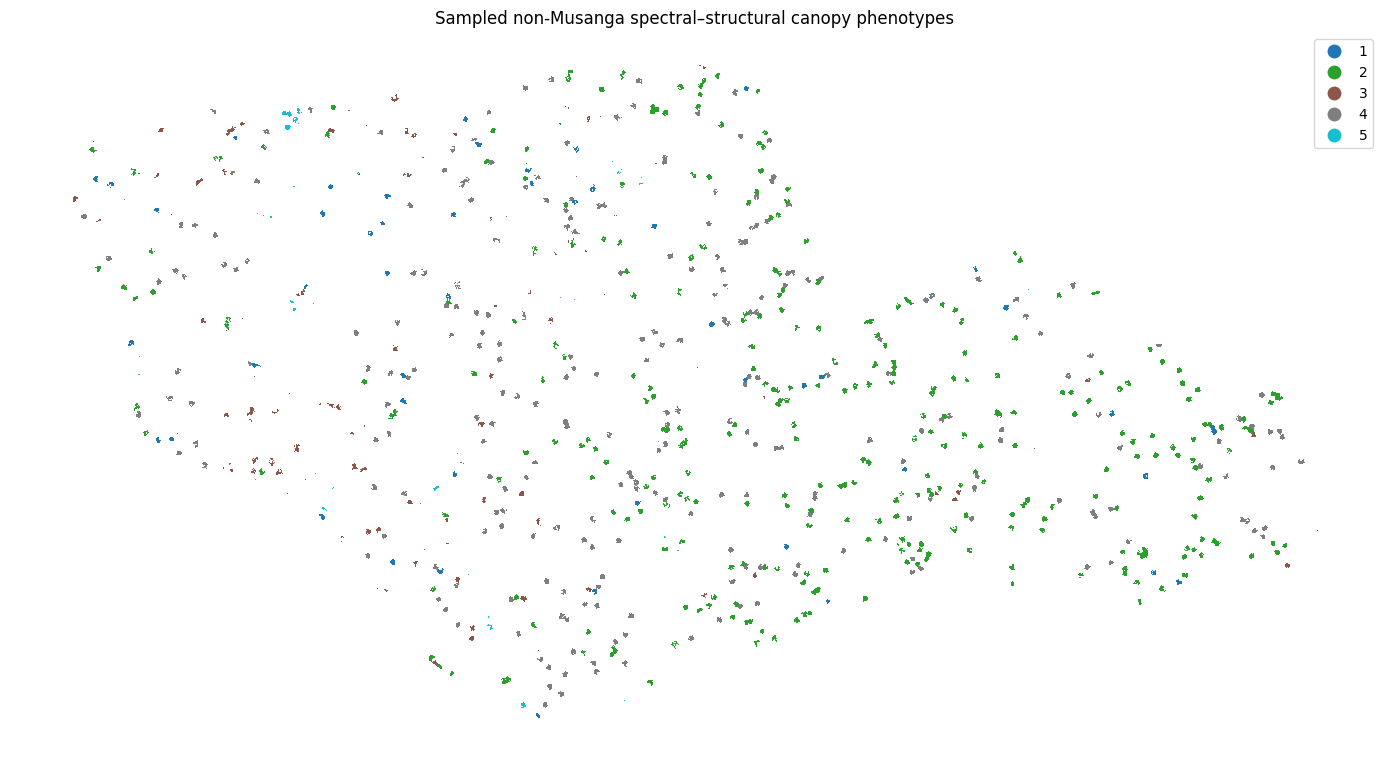

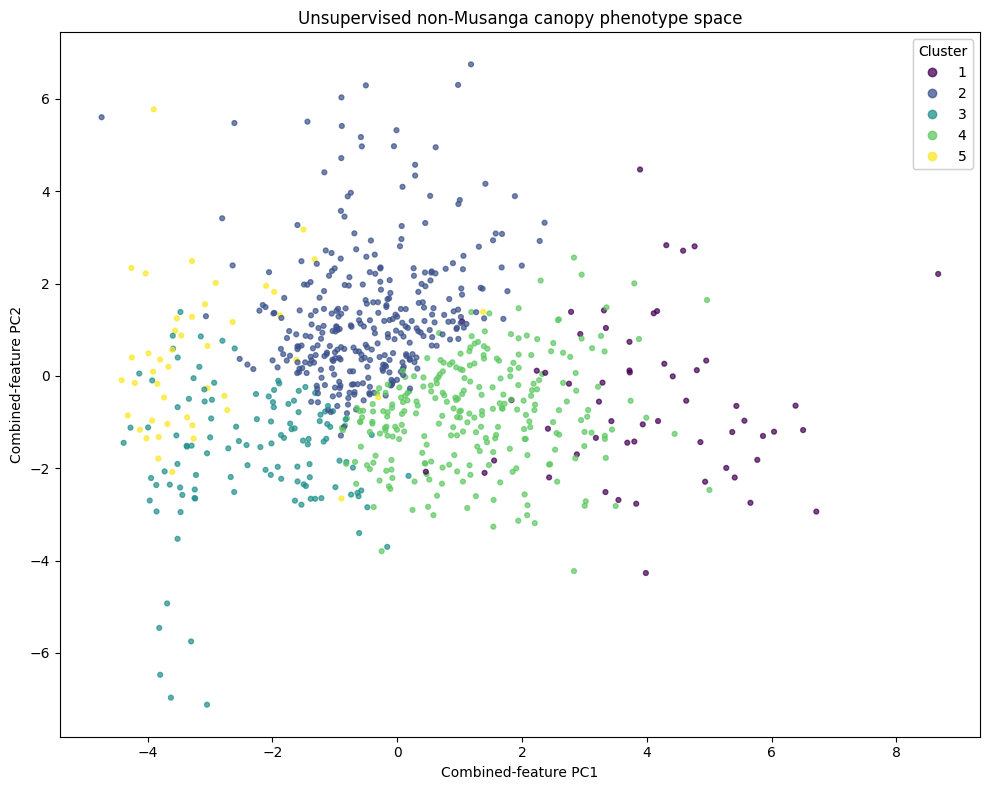

{
  "run_mode": "quick",
  "working_resolution_m": 0.28108,
  "n_sampled_objects": 800,
  "selected_k": 5,
  "embedding_model": "facebook/dinov2-small",
  "interpretation": "Clusters are candidate spectral-structural canopy phenotypes, not automatically botanical species.",
  "outputs": {
    "clustered_objects": "/content/drive/MyDrive/Colab Notebooks/Musanga/work/canopy_phenotypes/exports/sampled_canopy_phenotypes_quick.gpkg",
    "cluster_summary": "/content/drive/MyDrive/Colab Notebooks/Musanga/work/canopy_phenotypes/exports/phenotype_cluster_summary_quick.csv",
    "feature_table": "/content/drive/MyDrive/Colab Notebooks/Musanga/work/canopy_phenotypes/exports/sampled_object_features_quick.csv",
    "map": "/content/drive/MyDrive/Colab Notebooks/Musanga/work/canopy_phenotypes/figures/canopy_phenotype_map_quick.png",
    "galleries": "/content/drive/MyDrive/Colab Notebooks/Musanga/work/canopy_phenotypes/figures"
  }
}

Saved summary: /content/drive/MyDrive/Colab Notebooks/Musanga/wo

In [18]:

# ======================================================================================
# BLOCK 15 — EXPORT GEOSPATIAL OBJECTS, MAPS, AND MODEL COMPONENTS
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 15 — EXPORT GEOSPATIAL OBJECTS, MAPS, AND MODEL COMPONENTS")
print("=" * 100)

clustered_objects = sampled_objects.merge(
    feature_table[
        [
            "sample_index",
            "object_id",
            "phenotype_cluster",
            "distance_to_centroid",
            "chm_mean",
            "chm_median",
            "chm_std",
            "brightness_mean",
            "excess_green_mean",
            "edge_mean",
        ]
    ],
    on=["sample_index", "object_id"],
    how="inner",
    validate="one_to_one",
)

CLUSTERED_OBJECTS_PATH = (
    EXPORT_DIR
    / f"sampled_canopy_phenotypes_{mode_name}.gpkg"
)

clustered_objects.to_file(
    CLUSTERED_OBJECTS_PATH,
    layer="phenotypes",
    driver="GPKG",
)

CLUSTER_SUMMARY_PATH = (
    EXPORT_DIR
    / f"phenotype_cluster_summary_{mode_name}.csv"
)

FEATURE_EXPORT_PATH = (
    EXPORT_DIR
    / f"sampled_object_features_{mode_name}.csv"
)

cluster_summary.to_csv(
    CLUSTER_SUMMARY_PATH,
    index=False,
)

feature_table.to_csv(
    FEATURE_EXPORT_PATH,
    index=False,
)

cluster_selection.to_csv(
    EXPORT_DIR / f"cluster_selection_{mode_name}.csv",
    index=False,
)

joblib.dump(
    handcrafted_scaler,
    EXPORT_DIR / f"handcrafted_scaler_{mode_name}.joblib",
)

joblib.dump(
    embedding_pca,
    EXPORT_DIR / f"embedding_pca_{mode_name}.joblib",
)

joblib.dump(
    embedding_scaler,
    EXPORT_DIR / f"embedding_scaler_{mode_name}.joblib",
)

joblib.dump(
    phenotype_model,
    EXPORT_DIR / f"phenotype_kmeans_{mode_name}.joblib",
)

# Overview map.
figure, axis = plt.subplots(
    1,
    1,
    figsize=(14, 9),
)

clustered_objects.plot(
    column="phenotype_cluster",
    categorical=True,
    legend=True,
    linewidth=0,
    ax=axis,
)

axis.set_title(
    "Sampled non-Musanga spectral–structural canopy phenotypes"
)
axis.set_axis_off()

figure.tight_layout()

MAP_PATH = FIGURE_DIR / f"canopy_phenotype_map_{mode_name}.png"

figure.savefig(
    MAP_PATH,
    dpi=250,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)

# Two-dimensional feature-space view.
visual_pca = PCA(
    n_components=2,
    random_state=RANDOM_SEED,
)

coordinates = visual_pca.fit_transform(
    combined_features
)

figure, axis = plt.subplots(
    1,
    1,
    figsize=(10, 8),
)

scatter = axis.scatter(
    coordinates[:, 0],
    coordinates[:, 1],
    c=feature_table["phenotype_cluster"],
    s=12,
    alpha=0.7,
)

axis.set_xlabel("Combined-feature PC1")
axis.set_ylabel("Combined-feature PC2")
axis.set_title("Unsupervised non-Musanga canopy phenotype space")

legend = axis.legend(
    *scatter.legend_elements(),
    title="Cluster",
)

axis.add_artist(legend)
figure.tight_layout()

PCA_PATH = FIGURE_DIR / f"phenotype_feature_space_{mode_name}.png"

figure.savefig(
    PCA_PATH,
    dpi=220,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)

summary = {
    "run_mode": mode_name,
    "working_resolution_m": float(WORK_RESOLUTION),
    "n_sampled_objects": int(len(feature_table)),
    "selected_k": int(BEST_K),
    "embedding_model": EMBEDDING_MODEL_NAME,
    "interpretation": (
        "Clusters are candidate spectral-structural canopy phenotypes, "
        "not automatically botanical species."
    ),
    "outputs": {
        "clustered_objects": str(CLUSTERED_OBJECTS_PATH),
        "cluster_summary": str(CLUSTER_SUMMARY_PATH),
        "feature_table": str(FEATURE_EXPORT_PATH),
        "map": str(MAP_PATH),
        "galleries": str(FIGURE_DIR),
    },
}

SUMMARY_PATH = (
    EXPORT_DIR
    / f"canopy_phenotype_summary_{mode_name}.json"
)

SUMMARY_PATH.write_text(
    json.dumps(summary, indent=2)
)

print(json.dumps(summary, indent=2))
print("\nSaved summary:", SUMMARY_PATH)


## BLOCK 16 — Interpretation guidance

Before treating any phenotype as a species or species group, inspect the representative galleries and ask:

- Is the cluster visually coherent across spatially separated locations?
- Is it dominated by illumination, shadow, or image artefacts?
- Does it have a consistent canopy height and texture?
- Does it correspond to a recognizable crown architecture?
- Can field or botanical information confirm a taxonomic interpretation?

After the quick test succeeds, change in Block 03:

```python
QUICK_TEST = False
FORCE_REBUILD_PREPROCESSING = False
```

Then rerun from Block 03 onward. Existing working rasters will be reused, while the larger object sample and corresponding embeddings will be generated for the full experiment.
